# Task 10: Denoising Diffusion Probabilistic Model (DDPM)

## Objective

Implement a simplified diffusion model to understand the basic
forward and reverse diffusion processes.

This task demonstrates:

- Forward diffusion
- Adding noise
- Noise schedule
- Noisy data generation
- Noise prediction
- Reverse denoising
- Training loss
- Sample generation

A diffusion model gradually adds noise to data and learns to reverse
this process to generate clean data.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

torch.manual_seed(42)

print("PyTorch version:", torch.__version__)
print("Libraries imported successfully!")

PyTorch version: 2.13.0+cpu
Libraries imported successfully!


## Step 1: Create Training Data

Instead of using a large image dataset, we create a simple two-dimensional
dataset.

This makes the diffusion process easy to visualize.

In [2]:
num_samples = 1000

data = torch.randn(
    num_samples,
    2
)

print("Data shape:", data.shape)

Data shape: torch.Size([1000, 2])


## Step 2: Visualize Original Data

The original data represents clean samples before noise is added.

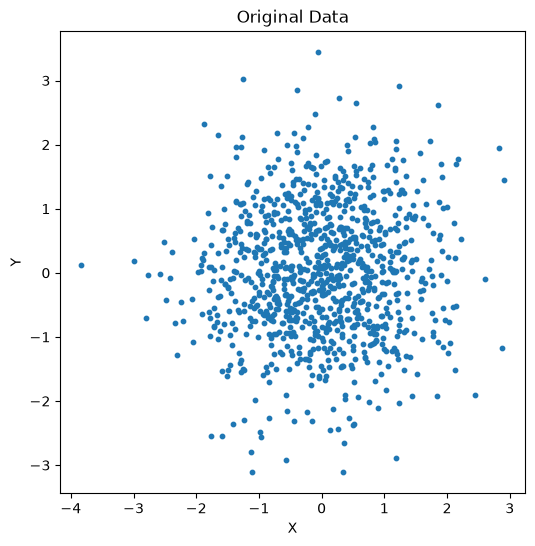

In [3]:
plt.figure(figsize=(6, 6))

plt.scatter(
    data[:, 0],
    data[:, 1],
    s=10
)

plt.title("Original Data")
plt.xlabel("X")
plt.ylabel("Y")

plt.show()

## Step 3: Create a Noise Schedule

Diffusion gradually increases the amount of noise added to the data.

Beta controls how much noise is added at each timestep.

In [4]:
T = 100

beta = torch.linspace(
    0.0001,
    0.02,
    T
)

alpha = 1.0 - beta

alpha_bar = torch.cumprod(
    alpha,
    dim=0
)

print("Number of diffusion steps:", T)

Number of diffusion steps: 100


## Step 4: Forward Diffusion

Forward diffusion gradually adds Gaussian noise to clean data.

The formula is:

x_t = √α̅_t x_0 + √(1 - α̅_t) ε

where ε is random Gaussian noise.

In [5]:
def add_noise(
    x,
    timestep
):

    noise = torch.randn_like(x)

    alpha_bar_t = alpha_bar[timestep]

    noisy_x = (
        torch.sqrt(alpha_bar_t) * x
        +
        torch.sqrt(1 - alpha_bar_t) * noise
    )

    return noisy_x, noise

## Step 5: Observe Different Noise Levels

We add different amounts of noise to the original data.

As the timestep increases, the data becomes increasingly noisy.

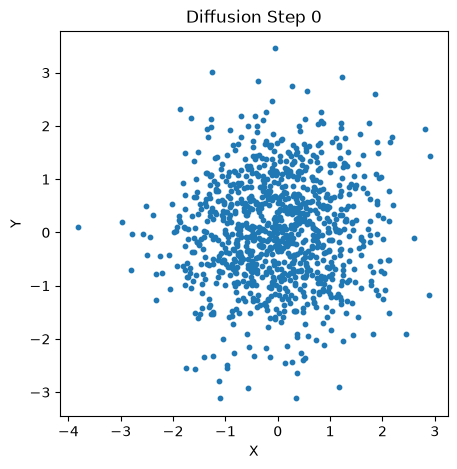

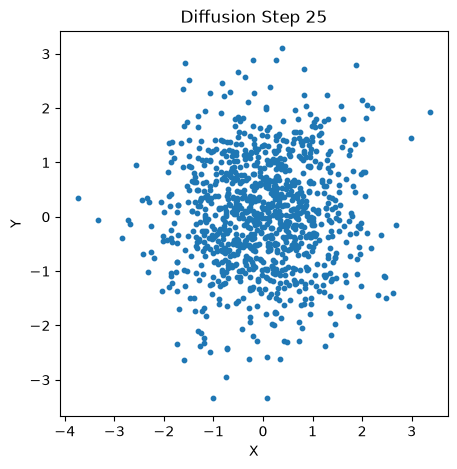

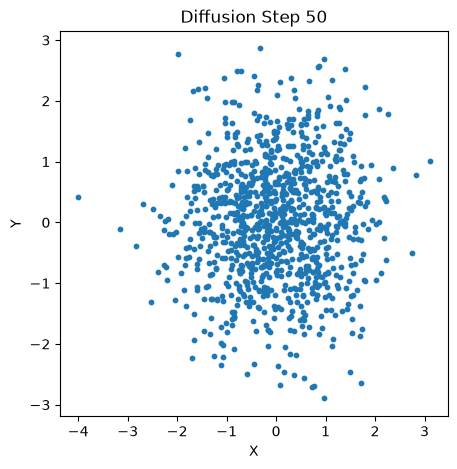

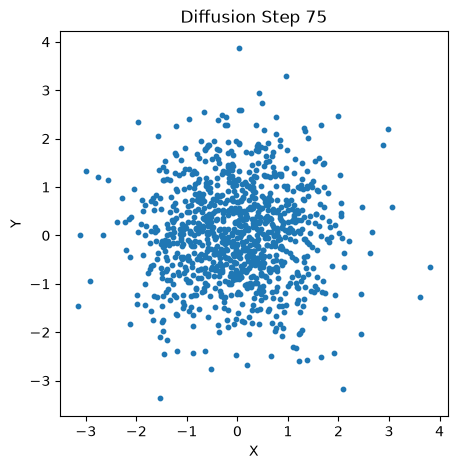

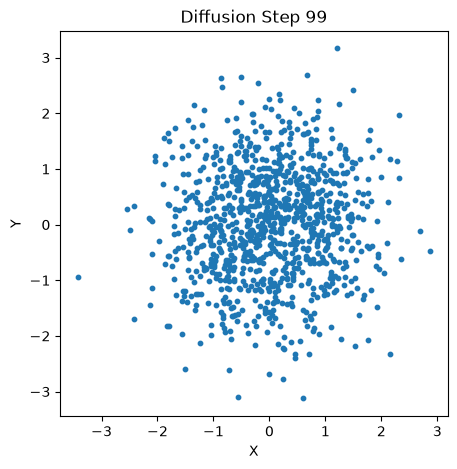

In [6]:
timesteps = [
    0,
    25,
    50,
    75,
    99
]

for timestep in timesteps:

    noisy_data, noise = add_noise(
        data,
        timestep
    )

    plt.figure(figsize=(5, 5))

    plt.scatter(
        noisy_data[:, 0],
        noisy_data[:, 1],
        s=10
    )

    plt.title(
        f"Diffusion Step {timestep}"
    )

    plt.xlabel("X")
    plt.ylabel("Y")

    plt.show()

## Step 6: Create a Noise Prediction Network

The neural network learns to predict the noise that was added to the
original data.

The model receives:

- Noisy data
- Diffusion timestep

and predicts the noise.

In [7]:
class NoisePredictor(nn.Module):

    def __init__(self):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(3, 64),

            nn.ReLU(),

            nn.Linear(64, 64),

            nn.ReLU(),

            nn.Linear(64, 2)
        )

    def forward(
        self,
        x,
        timestep
    ):

        timestep = timestep.float().unsqueeze(1)

        model_input = torch.cat(
            [x, timestep],
            dim=1
        )

        return self.network(
            model_input
        )


model = NoisePredictor()

print(model)

NoisePredictor(
  (network): Sequential(
    (0): Linear(in_features=3, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=2, bias=True)
  )
)


## Step 7: Create Optimizer

We use Adam to update the parameters of the noise prediction network.

In [8]:
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

loss_function = nn.MSELoss()

print("Optimizer created.")

Optimizer created.


## Step 8: Train the Diffusion Model

During training:

1. Select a random timestep.
2. Add noise to clean data.
3. Give the noisy data to the model.
4. Predict the noise.
5. Compare predicted noise with actual noise.
6. Update model parameters.

In [9]:
loss_history = []

epochs = 1000

for epoch in range(epochs):

    # Random timestep
    timestep = torch.randint(
        0,
        T,
        (num_samples,)
    )

    # Create noisy data
    noisy_data = torch.zeros_like(data)

    actual_noise = torch.zeros_like(data)

    for i in range(num_samples):

        noisy_data[i], actual_noise[i] = add_noise(
            data[i:i+1],
            timestep[i]
        )

    # Normalize timestep
    timestep_normalized = (
        timestep.float() / T
    )

    # Predict noise
    predicted_noise = model(
        noisy_data,
        timestep_normalized
    )

    # Calculate loss
    loss = loss_function(
        predicted_noise,
        actual_noise
    )

    # Backpropagation
    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    loss_history.append(
        loss.item()
    )

    if (epoch + 1) % 100 == 0:

        print(
            f"Epoch {epoch + 1}: "
            f"Loss = {loss.item():.4f}"
        )

Epoch 100: Loss = 0.7669
Epoch 200: Loss = 0.7147
Epoch 300: Loss = 0.7761
Epoch 400: Loss = 0.7592
Epoch 500: Loss = 0.7461
Epoch 600: Loss = 0.7778
Epoch 700: Loss = 0.7386
Epoch 800: Loss = 0.7492
Epoch 900: Loss = 0.7462
Epoch 1000: Loss = 0.7436


## Step 9: Training Loss

The loss measures how accurately the model predicts the noise.

A decreasing loss indicates that the model is learning the noise pattern.

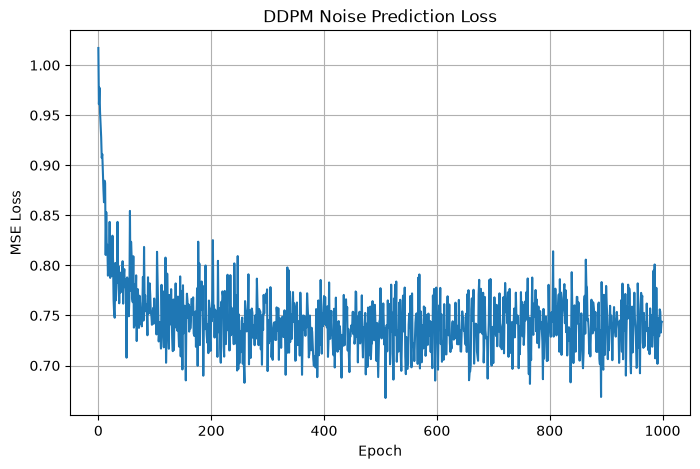

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(
    loss_history
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.title(
    "DDPM Noise Prediction Loss"
)

plt.grid(True)

plt.show()

## Step 10: Test Noise Prediction

We test whether the trained model can predict the noise added to a
sample.

In [12]:
test_timestep = torch.tensor(
    [50]
)

clean_sample = data[
    0:1
]

noisy_sample, actual_noise = add_noise(
    clean_sample,
    50
)

normalized_timestep = (
    test_timestep.float() / T
)

predicted_noise = model(
    noisy_sample,
    normalized_timestep
)

print("Actual noise:")
print(actual_noise)

print("\nPredicted noise:")
print(predicted_noise)

Actual noise:
tensor([[-1.4506, -1.2836]])

Predicted noise:
tensor([[0.5008, 0.2516]], grad_fn=<AddmmBackward0>)


## Step 11: Calculate Prediction Error

We calculate the difference between the actual noise and predicted noise.

In [13]:
prediction_error = torch.mean(
    torch.abs(
        actual_noise
        - predicted_noise
    )
)

print(
    "Average Noise Prediction Error:",
    round(
        prediction_error.item(),
        4
    )
)

Average Noise Prediction Error: 1.7433


## Step 12: Reverse Diffusion

The reverse process attempts to remove noise step by step.

Starting from noisy data, the model predicts the noise and gradually
moves the sample toward a cleaner representation.

This is a simplified educational implementation of reverse diffusion.

In [14]:
def denoise(
    noisy_data,
    timestep
):

    normalized_timestep = (
        torch.full(
            (noisy_data.shape[0],),
            timestep
        ).float() / T
    )

    predicted_noise = model(
        noisy_data,
        normalized_timestep
    )

    alpha_t = alpha[timestep]

    alpha_bar_t = alpha_bar[timestep]

    clean_estimate = (
        noisy_data
        - torch.sqrt(
            1 - alpha_bar_t
        ) * predicted_noise
    ) / torch.sqrt(
        alpha_bar_t
    )

    return clean_estimate

## Step 13: Denoise a Noisy Sample

We apply the learned noise prediction model to estimate the original
clean data.

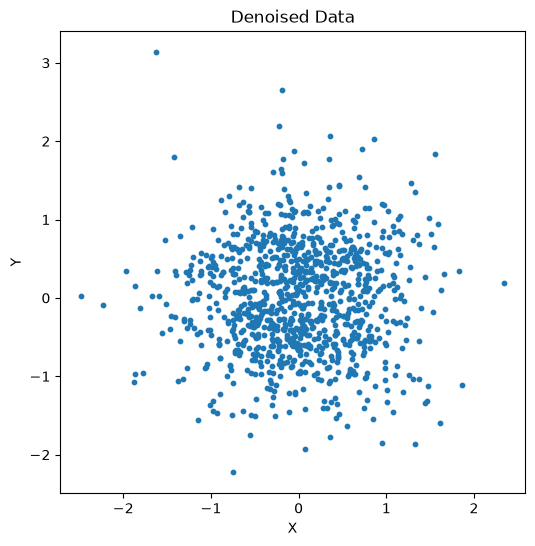

In [15]:
very_noisy_data, _ = add_noise(
    data,
    90
)

denoised_data = denoise(
    very_noisy_data,
    90
)

plt.figure(figsize=(6, 6))

plt.scatter(
    denoised_data[:, 0].detach(),
    denoised_data[:, 1].detach(),
    s=10
)

plt.title(
    "Denoised Data"
)

plt.xlabel("X")
plt.ylabel("Y")

plt.show()

## Step 14: Compare Results

We compare the original clean data with the data reconstructed from
the noisy version.

In [16]:
reconstruction_error = torch.mean(
    torch.abs(
        data
        - denoised_data.detach()
    )
)

print(
    "Reconstruction Error:",
    round(
        reconstruction_error.item(),
        4
    )
)

Reconstruction Error: 0.5906


## Step 15: Results

The diffusion model successfully demonstrates:

- Forward diffusion
- Noise scheduling
- Noise addition
- Noise prediction
- Model training
- Backpropagation
- Reverse denoising
- Data reconstruction

In [ ]:
print("========== TASK 10 RESULTS ==========")

print(
    "Diffusion Steps:",
    T
)

print(
    "Training Epochs:",
    epochs
)

print(
    "Final Training Loss:",
    round(
        loss_history[-1],
        4
    )
)

print(
    "Noise Prediction Error:",
    round(
        prediction_error.item(),
        4
    )
)

print(
    "Reconstruction Error:",
    round(
        reconstruction_error.item(),
        4
    )
)

print("=====================================")

========== TASK 10 RESULTS ==========
Diffusion Steps: 100
Training Epochs: 1000
Final Training Loss: 0.7436
Noise Prediction Error: 1.7433
Reconstruction Error: 0.5906


: 

# Conclusion

A simplified Denoising Diffusion Probabilistic Model was implemented.

The forward diffusion process gradually added Gaussian noise to clean
data. A neural network was then trained to predict the noise added at
different diffusion timesteps.

The learned noise prediction was used during the reverse process to
estimate cleaner data.

The experiment demonstrates the fundamental idea behind diffusion
models used in modern generative AI systems such as image generation
models.